# EfficientNet-B0 with Entropy Filtering and Ordinal Loss

This notebook trains an EfficientNet-B0 model with:
- **Entropy filtering**: Removes high-entropy samples for cleaner training
- **Ordinal loss**: Leverages the ordinal nature of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)

In [1]:
from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import os
import sys
sys.path.append('../../../')
from utils.dataset import PandasWithMilDataset
from utils.models import EfficientNetMIL

## Configuration

In [2]:
# Training parameters
seed = 42
batch_size = 8
num_workers = 4
output_classes = 5  # For ordinal encoding: ISUP 0-5 → 5 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.4
patience = 7

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../../..'
data_dir = '../../../..'
images_dir = '/home/woshington/Projects/Doutorado/bag_of_patches'

print(f"Data directory: {images_dir}")

# Output paths
os.makedirs('../logs', exist_ok=True)
os.makedirs('../models', exist_ok=True)
model_path = 'models/b0-mil.pth'
log_path = 'logs/b0-mil.txt'

Using device: cuda
Data directory: /home/woshington/Projects/Doutorado/bag_of_patches


## Ordinal Loss Function

Ordinal regression treats the problem as a series of binary classifications:
- For ISUP grade k, we predict k binary labels: [1,1,...,1,0,0,...,0]
- Example: ISUP 2 → [1, 1, 0, 0, 0] (grade > 0, grade > 1, but not > 2, > 3, > 4)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class BCEFocalOrdinalLoss(nn.Module):

    def __init__(self, gamma=2.0, w_focal=1.0, w_ord=1.0):
        super().__init__()

        self.gamma = gamma        
        self.w_focal = w_focal
        self.w_ord = w_ord

        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):

        targets = targets.to(logits.device).float()

        probs = torch.sigmoid(logits)

        # ----- BCE -----
        bce_loss = self.bce(logits, targets)

        # ----- FOCAL -----
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )

        p_t = probs * targets + (1 - probs) * (1 - targets)

        focal_weight = (1 - p_t) ** self.gamma

        focal_loss = (focal_weight * bce).mean()

        # ----- ORDINAL TERM -----

        expected_class = torch.sum(probs, dim=1)
        targets_class = torch.sum(targets, dim=1)

        max_class = logits.shape[1]

        ordinal_loss = torch.mean(
            (expected_class - targets_class) ** 2
        ) / (max_class ** 2)

        # ----- FINAL LOSS -----

        loss = (
            self.w_focal * focal_loss
            + self.w_ord * ordinal_loss
        )

        return loss

loss_function = BCEFocalOrdinalLoss()
print("Ordinal Regression Loss initialized")

Ordinal Regression Loss initialized


## Load Data with Entropy Filtering

In [4]:
# Load original training data
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Original records: {len(df_train_)}")

# Load entropy filtered samples
df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
print(f"High-entropy samples to remove: {len(df_entropy)}")

df_entropy_sorted = df_entropy.sort_values(by='difficulty_score', ascending=False).reset_index(drop=True)

print(df_entropy_sorted.head())
n_remove = int(len(df_entropy) * 0.2)

df_entropy_top = df_entropy_sorted.head(n_remove)

# Maneira Correta
print("max_entropy", df_entropy_top["isup_grade"].value_counts())
# Filter out high-entropy samples
df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top['image_id'])].reset_index(drop=True)
print(f"Filtered records: {len(df_train_)}")

# Clean column names
df_train_.columns = df_train_.columns.str.strip()

# Split by fold (fold 3 for validation)
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Load test data
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

def remove_nonexistent_images(df, images_dir):
    """
    Remove rows from df where the image does not exist in images_dir.
    """
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, x))
    existent_images = [os.path.isdir(path) for path in image_ids]
    df = df[existent_images]
    return df

df_train = remove_nonexistent_images(df_train, images_dir)
df_val = remove_nonexistent_images(df_val, images_dir)
df_test = remove_nonexistent_images(df_test, images_dir)

print(f"\nTrain: {len(df_train)} samples")
print(f"Validation: {len(df_val)} samples")
print(f"Test: {len(df_test)} samples")

# Check class distribution
print(f"\nTrain class distribution:")
print(df_train['isup_grade'].value_counts().sort_index())

Original records: 9024
High-entropy samples to remove: 903
                           image_id data_provider  isup_grade gleason_score  \
0  e0f8b96960ada384a00e493545f783da       radboud           5           5+5   
1  c3f6dfc5c801b1f2aed4c9e318bd015d       radboud           5           5+5   
2  35c7912e941c9bf21594deeda6c891e2       radboud           3           4+3   
3  a4514f8a6800bf122ae746c4f573ee6f       radboud           5           5+5   
4  0a8c2bda6e00a040372185ccd9a3c4ab    karolinska           5           4+5   

   fold             image_id_from_results  true_label  pred_b0  entropy_b0  \
0     1  e0f8b96960ada384a00e493545f783da         5.0      3.0    0.646624   
1     2  c3f6dfc5c801b1f2aed4c9e318bd015d         5.0      0.0    0.114379   
2     0  35c7912e941c9bf21594deeda6c891e2         3.0      4.0         NaN   
3     0  a4514f8a6800bf122ae746c4f573ee6f         5.0      4.0    0.327839   
4     0  0a8c2bda6e00a040372185ccd9a3c4ab         5.0      4.0    0.319212  

## Data Augmentation

In [5]:
# Augmentation for training
train_transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
])

# No augmentation for validation/test
val_transforms = None

## Create Datasets and DataLoaders

In [6]:
from torch.utils.data import SequentialSampler

# Create datasets
train_dataset = PandasWithMilDataset(images_dir, df_train, transforms=train_transforms)
valid_dataset = PandasWithMilDataset(images_dir, df_val,   transforms=val_transforms)
test_dataset  = PandasWithMilDataset(images_dir, df_test,  transforms=val_transforms)

print(f"Train samples: {len(train_dataset)}")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(train_dataset),
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,
    drop_last=True,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size * 2,
    num_workers=num_workers,
    sampler=SequentialSampler(valid_dataset),
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size * 2,
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,
)

print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches:       {len(test_loader)}")

Train samples: 7073
Train batches:      884
Validation batches: 111
Test batches:       100


## Model Setup

In [7]:
load_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model = EfficientNetMIL(
    model=load_model,
    output_classes=output_classes,
    dropout_rate=dropout_rate,
    hidden_dim=512,
    gated=True,
    pool="att",
)
model = model.to(device)

## Optimizer and Scheduler

In [8]:
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=init_lr / warmup_factor)

# Scheduler with warmup
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(
    optimizer,
    multiplier=warmup_factor,
    total_epoch=warmup_epochs,
    after_scheduler=scheduler_cosine
)

print("Optimizer and scheduler configured")

Optimizer and scheduler configured


## Training and Validation Functions

In [9]:
def training_step(model, dataloader, optimizer, device, loss_fn, scaler):
    """
    Treina uma época completa.
    Espera batches de (bag, mask, label, img_id) do PandasWithMilDataset.
    """
    model.train()
    train_loss = []

    bar = tqdm(dataloader, desc="Training")

    for bag, mask, targets, _img_ids in bar:
        bag     = bag.to(device, non_blocking=True)       # (B, N, C, H, W)
        mask    = mask.to(device, non_blocking=True)      # (B, N)
        targets = targets.to(device, non_blocking=True)   # (B, num_classes)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out  = model(bag, mask)                       # dict com 'logits', 'attn', 'features'
            loss = loss_fn(out["logits"], targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_val    = loss.detach().cpu().item()
        train_loss.append(loss_val)
        smooth_loss = sum(train_loss[-100:]) / min(len(train_loss), 100)

        bar.set_postfix(loss=f"{loss_val:.5f}", smooth=f"{smooth_loss:.5f}")

    return train_loss


def validation_step(model, dataloader, device, loss_fn):
    """
    Avalia no conjunto de validação.
    """
    model.eval()

    val_loss    = []
    all_preds   = []
    all_targets = []

    bar = tqdm(dataloader, desc="Validation")

    with torch.no_grad():
        for bag, mask, targets, _img_ids in bar:
            bag     = bag.to(device, non_blocking=True)
            mask    = mask.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                out  = model(bag, mask)
                loss = loss_fn(out["logits"], targets)

            probs       = torch.sigmoid(out["logits"])
            predictions = (probs > 0.5).sum(dim=1)          # decodifica ordinal → classe
            targets_cls = targets.sum(dim=1).long()

            all_preds.append(predictions.cpu())
            all_targets.append(targets_cls.cpu())
            val_loss.append(loss.cpu().item())

    all_preds   = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    return {
        "val_loss":      np.mean(val_loss),
        "val_acc":       accuracy_score(all_targets, all_preds),
        "val_kappa":     cohen_kappa_score(all_targets, all_preds, weights="quadratic"),
        "val_f1":        f1_score(all_targets, all_preds, average="macro", zero_division=0),
        "val_recall":    recall_score(all_targets, all_preds, average="macro", zero_division=0),
        "val_precision": precision_score(all_targets, all_preds, average="macro", zero_division=0),
    }

## Training Loop

In [10]:
best_kappa = 0.0
best_epoch = 0
epochs_without_improvement = 0

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_kappa': [],
    'val_f1': [],
    'val_recall': [],
    'val_precision': []
}

print("\nStarting training...\n")
print("="*80)

scaler = torch.amp.GradScaler()


for epoch in range(1, n_epochs + 1):
    print(f"\nEpoch {epoch}/{n_epochs}")
    print("-" * 80)
    
    # Train
    train_loss = training_step(model, train_loader, optimizer, device, loss_function, scaler)
    
    # Validate
    metrics = validation_step(model, valid_loader, device, loss_function)
    
    # Update scheduler
     # Update scheduler
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0] 
    
    # Save history
    history['train_loss'].append(np.mean(train_loss))
    history['val_loss'].append(metrics['val_loss'])
    history['val_acc'].append(metrics['val_acc'])
    history['val_kappa'].append(metrics['val_kappa'])
    history['val_f1'].append(metrics['val_f1'])
    history['val_recall'].append(metrics['val_recall'])
    history['val_precision'].append(metrics['val_precision'])
    
    # Print metrics
    print(f"\nResults:")
    print(f"  Train Loss: {history['train_loss'][-1]:.5f}")
    print(f"  Val Loss: {metrics['val_loss']:.5f}")
    print(f"  Val Accuracy: {metrics['val_acc']*100:.2f}%")
    print(f"  Val Kappa: {metrics['val_kappa']:.4f}")
    print(f"  Val F1: {metrics['val_f1']:.4f}")
    print(f"  Learning Rate: {current_lr:.2e}")
    
    # Log to file
    log_line = f"epoch: {epoch} | lr: {current_lr:.2e} | train_loss: {history['train_loss'][-1]:.5f} | val_loss: {metrics['val_loss']:.5f} | val_acc: {metrics['val_acc']:.4f} | val_kappa: {metrics['val_kappa']:.4f}\n"
    with open(log_path, 'a') as f:
        f.write(log_line)
    
    # Save best model
    if metrics['val_kappa'] > best_kappa:
        best_kappa = metrics['val_kappa']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_path)
        print(f"\n  ✓ Best model saved! Kappa: {best_kappa:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"\n  No improvement for {epochs_without_improvement} epoch(s)")
    
    # Early stopping
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {best_epoch} with Kappa: {best_kappa:.4f}")
        break

print("\n" + "="*80)
print("Training completed!")
print(f"Best validation Kappa: {best_kappa:.4f} at epoch {best_epoch}")
print("="*80)


Starting training...


Epoch 1/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 111/111 [01:09<00:00,  1.60it/s]



Results:
  Train Loss: 0.17910
  Val Loss: 0.12881
  Val Accuracy: 59.25%
  Val Kappa: 0.7922
  Val F1: 0.5020
  Learning Rate: 3.00e-04

  ✓ Best model saved! Kappa: 0.7922

Epoch 2/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 111/111 [01:12<00:00,  1.53it/s]
/home/woshington/Projects/Doutorado/repo/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1087: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)



Results:
  Train Loss: 0.15492
  Val Loss: 0.11383
  Val Accuracy: 60.78%
  Val Kappa: 0.8261
  Val F1: 0.5447
  Learning Rate: 3.00e-04

  ✓ Best model saved! Kappa: 0.8261

Epoch 3/50
--------------------------------------------------------------------------------


...


Results:
  Train Loss: 0.03830
  Val Loss: 0.14070
  Val Accuracy: 67.86%
  Val Kappa: 0.8580
  Val F1: 0.6227
  Learning Rate: 3.00e-04

  No improvement for 5 epoch(s)

Epoch 31/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 111/111 [01:10<00:00,  1.58it/s]



Results:
  Train Loss: 0.03442
  Val Loss: 0.14803
  Val Accuracy: 68.31%
  Val Kappa: 0.8578
  Val F1: 0.6258
  Learning Rate: 3.00e-04

  No improvement for 6 epoch(s)

Epoch 32/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 111/111 [01:10<00:00,  1.58it/s]



Results:
  Train Loss: 0.03493
  Val Loss: nan
  Val Accuracy: 66.84%
  Val Kappa: 0.8550
  Val F1: 0.6115
  Learning Rate: 3.00e-04

  No improvement for 7 epoch(s)

Early stopping at epoch 32
Best epoch: 25 with Kappa: 0.8619

Training completed!
Best validation Kappa: 0.8619 at epoch 25


## Plot Training History

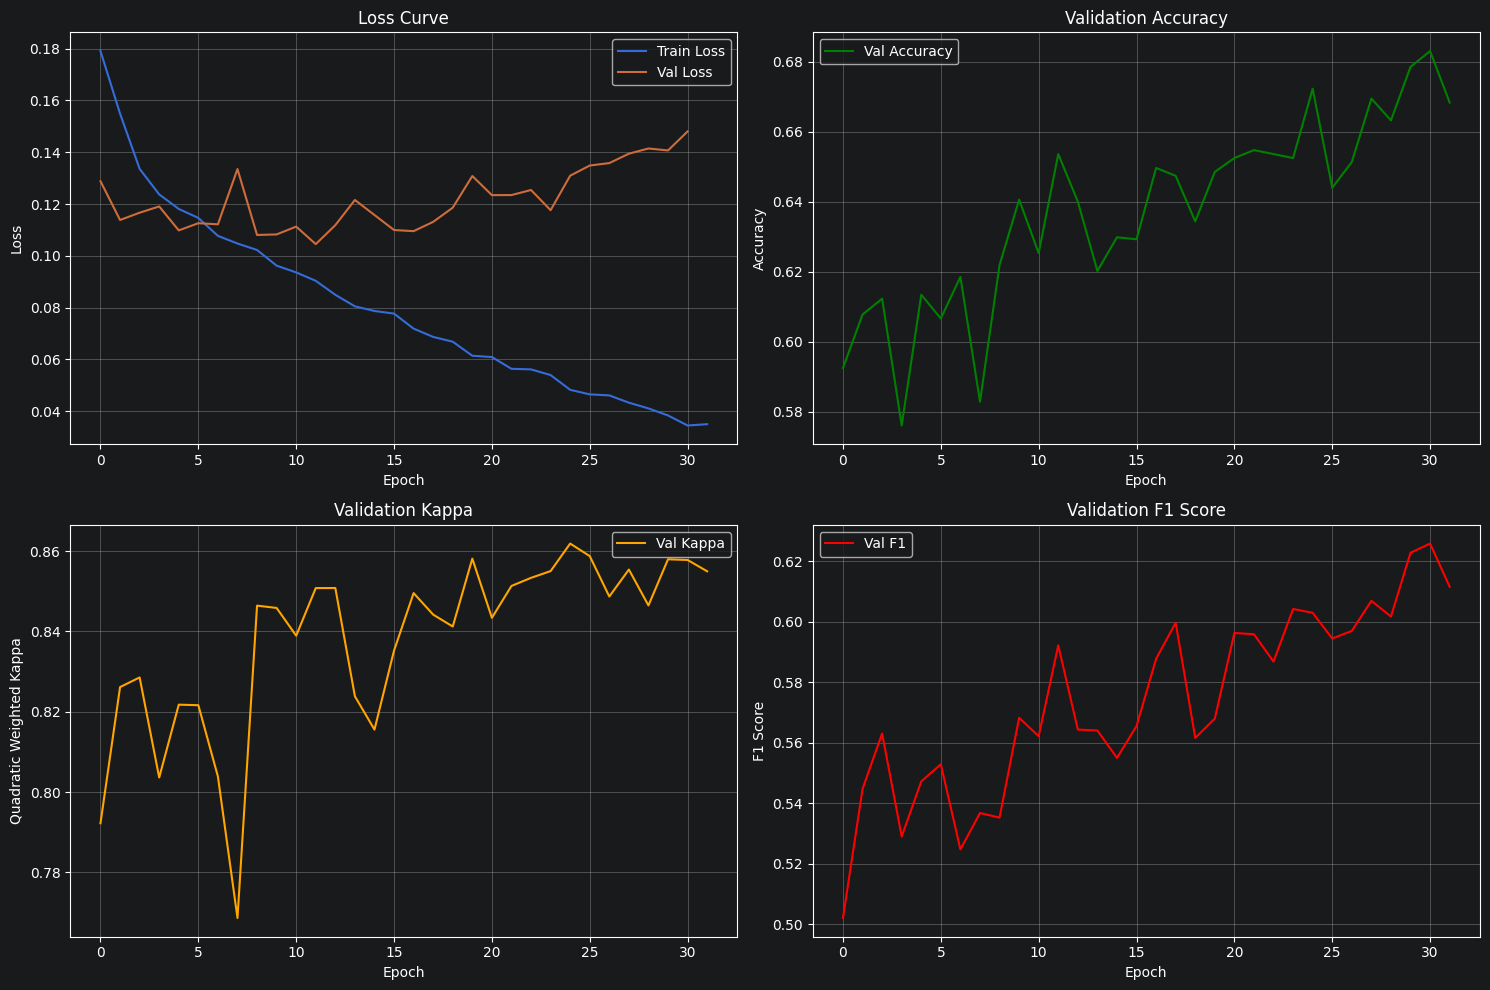

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curve')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Kappa
axes[1, 0].plot(history['val_kappa'], label='Val Kappa', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Quadratic Weighted Kappa')
axes[1, 0].set_title('Validation Kappa')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-training.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

In [12]:
from utils.metrics import evaluation, format_metrics

model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

# ── avaliação no test set ────────────────────────────────────────────
all_preds   = []
all_targets = []

with torch.no_grad():
    for bag, mask, targets, _img_ids in tqdm(test_loader, desc="Testing"):
        bag  = bag.to(device,  non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out = model(bag, mask)

        probs       = torch.sigmoid(out["logits"])
        predictions = (probs > 0.5).sum(dim=1)
        targets_cls = targets.sum(dim=1).long()

        all_preds.append(predictions.cpu())
        all_targets.append(targets_cls.cpu())

all_preds   = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

test_acc   = accuracy_score(all_targets, all_preds)
test_kappa = cohen_kappa_score(all_targets, all_preds, weights="quadratic")
test_f1    = f1_score(all_targets, all_preds, average="macro", zero_division=0)

print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"Accuracy : {test_acc*100:.2f}%")
print(f"Kappa    : {test_kappa:.4f}")
print(f"Macro F1 : {test_f1:.4f}")
print("="*60)

Testing: 100%|██████████| 100/100 [01:09<00:00,  1.44it/s]


TEST SET RESULTS
Accuracy : 66.92%
Kappa    : 0.8531
Macro F1 : 0.5983


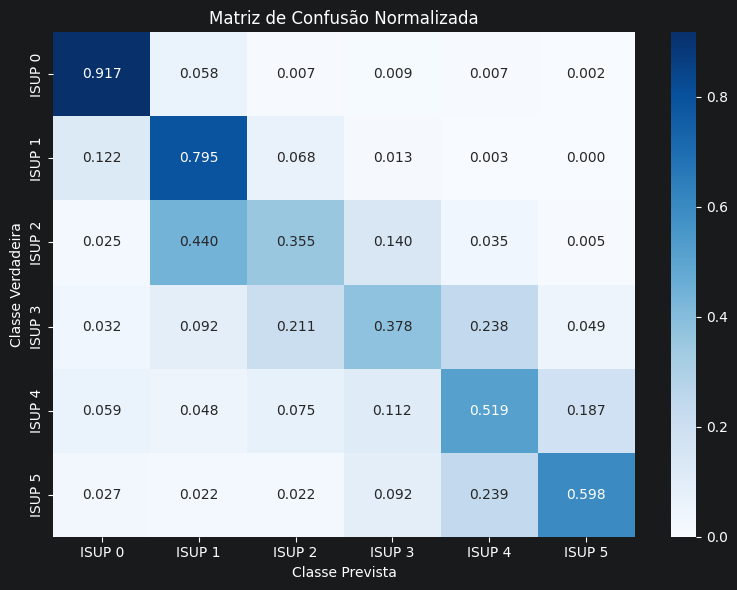

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_targets, all_preds)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Normalização por linha (cada linha soma 1)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Labels das classes (ajuste conforme necessário)
classes = ['ISUP 0', 'ISUP 1', 'ISUP 2', 'ISUP 3', 'ISUP 4', 'ISUP 5']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.title("Matriz de Confusão Normalizada")
plt.ylabel("Classe Verdadeira")
plt.xlabel("Classe Prevista")
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-confusion-matrix-normalized.png', dpi=300, bbox_inches='tight')
plt.show()


## Summary

This notebook trained EfficientNet-B0 with:
1. **Entropy filtering** - Removed high-entropy samples for cleaner training data
2. **Ordinal loss** - Leveraged the ordered nature of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)

The ordinal approach enforces the constraint that predictions should respect the natural ordering of grades, potentially improving performance on ordinal classification tasks like cancer grading.